In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dropout,
    Flatten,
    Dense
)

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv("fashion-mnist_test.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.isnull().sum()

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64

In [8]:
X = df.drop("label", axis=1).values
y = df["label"].values

In [9]:
X = X / 255.0

In [10]:
X = X.reshape(-1, 28, 28, 1)

In [11]:
y = to_categorical(y, 10)

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
model = Sequential()

In [14]:
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))


c:\Users\skadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.add(MaxPooling2D((2,2)))

In [16]:
model.add(Dropout(0.25))

In [17]:
model.add(Conv2D(64,(3,3),activation='relu'))

In [18]:
model.add(MaxPooling2D((2,2)))

# Dropout Layer
model.add(Dropout(0.25))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

In [19]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [20]:
history = model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5808 - loss: 1.1359 - val_accuracy: 0.7556 - val_loss: 0.6435
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7423 - loss: 0.6977 - val_accuracy: 0.7956 - val_loss: 0.5499
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7664 - loss: 0.6133 - val_accuracy: 0.8169 - val_loss: 0.5125
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7942 - loss: 0.5543 - val_accuracy: 0.8363 - val_loss: 0.4533
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8114 - loss: 0.5099 - val_accuracy: 0.8500 - val_loss: 0.4247
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8255 - loss: 0.4773 - val_accuracy: 0.8625 - val_loss: 0.4079
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8308 - loss: 0.4618 - val_accuracy: 0.8587 - val_loss: 0.3895
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8402 - loss: 0.4328 - val_accuracy: 0.

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8690 - loss: 0.3781

Test Accuracy: 0.8690000176429749


In [22]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [23]:
print("\nClassification Report:\n")

print(
    classification_report(
        true_classes,
        predicted_classes
    )
)


Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       192
           1       0.98      0.96      0.97       192
           2       0.78      0.84      0.81       212
           3       0.87      0.93      0.90       205
           4       0.76      0.82      0.79       204
           5       0.97      0.98      0.98       193
           6       0.67      0.50      0.57       200
           7       0.92      0.95      0.94       206
           8       0.99      0.96      0.98       196
           9       0.97      0.94      0.95       200

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



In [24]:
cm = confusion_matrix(true_classes,predicted_classes)
print("\nConfusion Matrix:\n")
print(cm)


Confusion Matrix:

[[157   1   2  10   0   0  22   0   0   0]
 [  1 184   0   7   0   0   0   0   0   0]
 [  2   0 178   0  22   0  10   0   0   0]
 [  5   1   3 190   2   0   4   0   0   0]
 [  0   0  21   6 167   0  10   0   0   0]
 [  0   0   0   0   0 189   0   3   1   0]
 [ 41   1  24   6  28   0 100   0   0   0]
 [  0   0   0   0   0   4   0 196   0   6]
 [  0   0   1   0   0   1   3   2 189   0]
 [  0   0   0   0   0   0   0  12   0 188]]


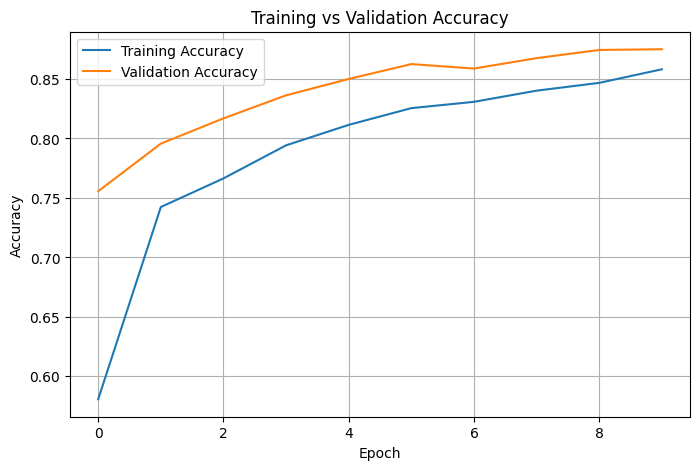

In [25]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()